In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r'D:\bmi\Tech_Tapper\core_ml\data\synthetic_project_data.csv')
df.head()

,Project_ID,Update_Day,Planned_Cost,Planned_Labour,Planned_Material,Actual_Cost,Actual_Labour,Actual_Material,%Work_Completed,External_Delay,Internal_Delay,Delay_Label
0,PROJ_00001,2025-07-13,6.886484e+11,116,3.676744e+11,7.479917e+11,134,4.344315e+11,59.69,4,1,False
1,PROJ_00002,2024-01-20,2.931375e+12,262,1.259270e+12,2.051962e+12,215,8.814892e+11,29.12,4,3,False
2,PROJ_00003,2023-10-23,1.328577e+11,62,4.906013e+10,9.300041e+10,50,3.434209e+10,24.10,5,3,True
3,PROJ_00004,2024-07-05,1.245545e+10,493,5.970769e+09,1.215167e+10,598,6.012719e+09,92.19,2,2,False
4,PROJ_00005,2024-06-04,5.473492e+11,50,2.128543e+11,3.831445e+11,44,1.489980e+11,16.53,1,2,False


In [3]:
df.columns

Index(['Project_ID', 'Update_Day', 'Planned_Cost', 'Planned_Labour',
       'Planned_Material', 'Actual_Cost', 'Actual_Labour', 'Actual_Material',
       '%Work_Completed', 'External_Delay', 'Internal_Delay', 'Delay_Label'],
      dtype='object')

In [4]:
df.sample()

,Project_ID,Update_Day,Planned_Cost,Planned_Labour,Planned_Material,Actual_Cost,Actual_Labour,Actual_Material,%Work_Completed,External_Delay,Internal_Delay,Delay_Label
794,PROJ_00795,2025-07-22,1.152152e+12,119,4.162488e+11,1.255958e+12,109,4.039730e+11,76.67,1,2,False


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Project_ID        1000 non-null   object 
 1   Update_Day        1000 non-null   object 
 2   Planned_Cost      1000 non-null   float64
 3   Planned_Labour    1000 non-null   int64  
 4   Planned_Material  1000 non-null   float64
 5   Actual_Cost       1000 non-null   float64
 6   Actual_Labour     1000 non-null   int64  
 7   Actual_Material   1000 non-null   float64
 8   %Work_Completed   1000 non-null   float64
 9   External_Delay    1000 non-null   int64  
 10  Internal_Delay    1000 non-null   int64  
 11  Delay_Label       1000 non-null   bool   
dtypes: bool(1), float64(5), int64(4), object(2)
memory usage: 87.0+ KB


In [6]:
numeric_col = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

categorial_col = df.select_dtypes(include=['object']).columns.tolist()

print("Number of numeric columns: ", len(numeric_col))
print("Sample of numeric columns: ", numeric_col[:10])
print("Number of categorial columns: ", len(categorial_col))
print("Sample of categorial columns: ", categorial_col[:10])

Number of numeric columns:  9
Sample of numeric columns:  ['Planned_Cost', 'Planned_Labour', 'Planned_Material', 'Actual_Cost', 'Actual_Labour', 'Actual_Material', '%Work_Completed', 'External_Delay', 'Internal_Delay']
Number of categorial columns:  2
Sample of categorial columns:  ['Project_ID', 'Update_Day']


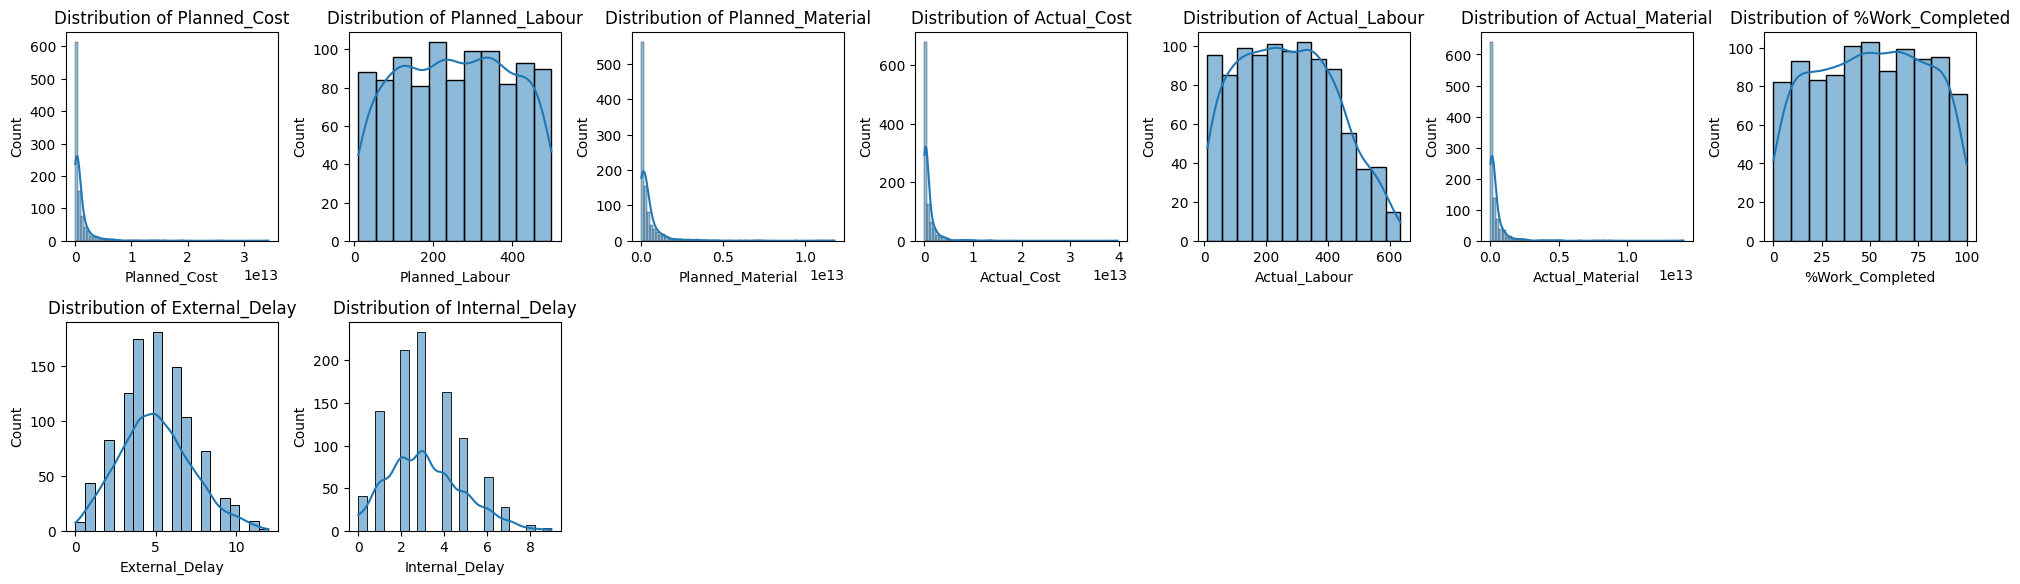

In [7]:
plt.figure(figsize=(20,20))
for i , col in enumerate(numeric_col):
    plt.subplot(7,7,i+1)
    sns.histplot(data=df, x=col, kde=True)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.title(f"Distribution of {col}")
plt.show()

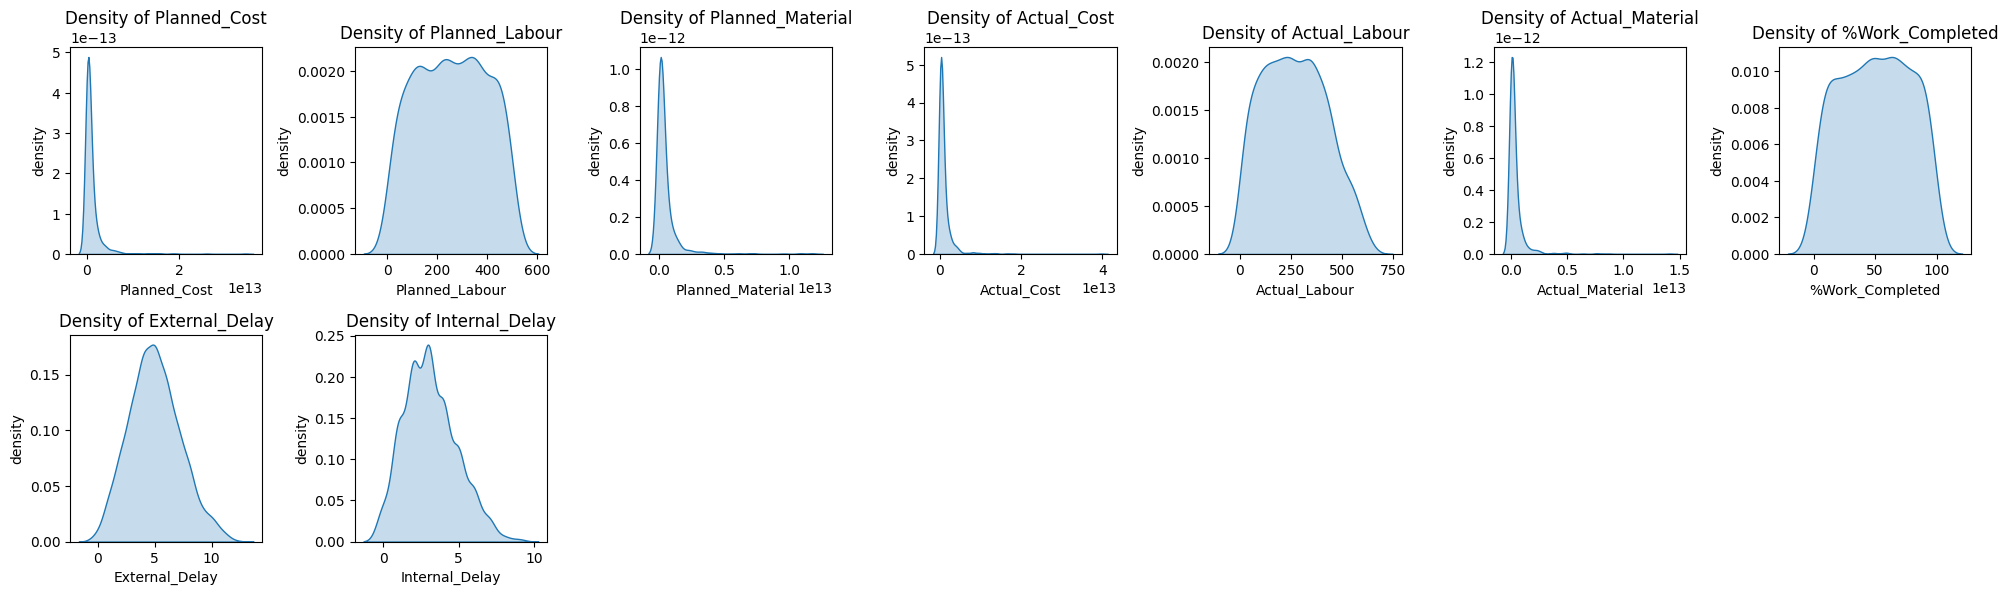

In [8]:
plt.figure(figsize=(20,20))
for i , col in enumerate(numeric_col):
    plt.subplot(7,7,i+1)
    sns.kdeplot(data=df, x=col , fill=True)
    plt.xlabel(col)
    plt.ylabel("density")
    plt.tight_layout()
    plt.title(f"Density of {col}")
plt.show()

In [9]:
for col in numeric_col:
    print(f"{col}:")
    print("Skewness: %f" % df[col].skew())
    print("Kurtosis: %f" % df[col].kurt())

Planned_Cost:
Skewness: 6.889133
Kurtosis: 68.097743
Planned_Labour:
Skewness: -0.012824
Kurtosis: -1.158014
Planned_Material:
Skewness: 6.345619
Kurtosis: 51.548474
Actual_Cost:
Skewness: 8.225084
Kurtosis: 108.468784
Actual_Labour:
Skewness: 0.207416
Kurtosis: -0.864057
Actual_Material:
Skewness: 6.998109
Kurtosis: 70.563341
%Work_Completed:
Skewness: -0.032106
Kurtosis: -1.157613
External_Delay:
Skewness: 0.281320
Kurtosis: -0.173936
Internal_Delay:
Skewness: 0.472969
Kurtosis: -0.084514


In [ ]:

def feature_engineering(data):
    df_features = df.copy()

    df_features['cost_over_run'] = df['Planned_Cost']- df['Actual_Cost']
    df_features["is_cost_overrun"] = np.where(df_features['cost_over_run']>0, 1, 0)

    # Convert Update_Day to datetime and extract features
    df_features['Update_Day'] = pd.to_datetime(df_features['Update_Day'])
    df_features['Update_Month'] = df_features['Update_Day'].dt.month
    df_features['Update_Quarter'] = df_features['Update_Day'].dt.quarter
    df_features['Days_Since_Start'] = (df_features['Update_Day'] - df_features['Update_Day'].min()).dt.days

    # Cost and budget ratios
    df_features['Planned_Cost_Millions'] = df_features['Planned_Cost'] / 1e6
    df_features['Actual_Cost_Millions'] = df_features['Actual_Cost'] / 1e6
    df_features['Material_Cost_Ratio'] = df_features['Planned_Material'] / df_features['Planned_Cost']
    df_features['Labour_Per_Million'] = df_features['Planned_Labour'] / (df_features['Planned_Cost'] / 1e6)

    # Efficiency and performance metrics
    df_features['Labour_Efficiency'] = df_features['Actual_Labour'] / df_features['Planned_Labour']
    df_features['Material_Efficiency'] = df_features['Actual_Material'] / df_features['Planned_Material']
    df_features['Cost_Efficiency'] = df_features['Actual_Cost'] / df_features['Planned_Cost']

    # Delay-related features
    df_features['Total_Delay'] = df_features['External_Delay'] + df_features['Internal_Delay']
    df_features['Delay_Ratio'] = df_features['External_Delay'] / (df_features['Internal_Delay'] + 1)
    df_features['Delay_Per_Work_Completed'] = df_features['Total_Delay'] / (df_features['%Work_Completed'] + 1)

    # Project complexity indicators
    df_features['Project_Size_Category'] = pd.cut(df_features['Planned_Cost_Millions'], 
                                                bins=[0, 100, 1000, 10000, float('inf')], 
                                                labels=['Small', 'Medium', 'Large', 'Mega'])

    # Performance vs expectation
    df_features['Work_Delay_Interaction'] = df_features['%Work_Completed'] * df_features['Total_Delay']
    df_features['Cost_Work_Ratio'] = df_features['Actual_Cost_Millions'] / (df_features['%Work_Completed'] + 1)

    # Risk indicators
    df_features['High_External_Delay'] = (df_features['External_Delay'] > df_features['External_Delay'].quantile(0.75)).astype(int)
    df_features['High_Internal_Delay'] = (df_features['Internal_Delay'] > df_features['Internal_Delay'].quantile(0.75)).astype(int)
    df_features['Low_Work_Progress'] = (df_features['%Work_Completed'] < 50).astype(int)
    return df_features


new_features = ['cost_over_run', 'is_cost_overrun', 'Update_Month', 'Update_Quarter',
                'Days_Since_Start', 'Planned_Cost_Millions', 'Actual_Cost_Millions',
                'Material_Cost_Ratio', 'Labour_Per_Million', 'Labour_Efficiency',
                'Material_Efficiency', 'Cost_Efficiency', 'Total_Delay', 'Delay_Ratio',
                'Delay_Per_Work_Completed', 'Work_Delay_Interaction',]

df_features = feature_engineering(df)

print(f"Original features: {df.shape[1]}")
print(f"After feature engineering: {df_features.shape[1]}")
print(f"New features created: {df_features.shape[1] - df.shape[1]}")

Original features: 12
After feature engineering: 33
New features created: 21


In [13]:
X = df_features[new_features]
y = df_features['is_cost_overrun']

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, classification_report, confusion_matrix
)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define models to try
models_to_try = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM': SVC(probability=True, random_state=42)
}

# Store results
model_results = []

for name, model in models_to_try.items():
    print(f"\nTraining {name}...")
    
    # Use scaled data for SVM and Logistic Regression
    if name in ['SVM', 'Logistic Regression']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_pred_proba)

    # Save results
    model_results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC-AUC': auc
    })
    
    # Extra: print classification report
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Convert results to DataFrame
results_df = pd.DataFrame(model_results)
print("\nFinal Comparison:\n", results_df)


Training Random Forest...
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        95
           1       1.00      1.00      1.00       105

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

Confusion Matrix:
 [[ 95   0]
 [  0 105]]

Training Gradient Boosting...
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        95
           1       1.00      1.00      1.00       105

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

Confusion Matrix:
 [[ 95   0]
 [  0 105]]

Training Logistic Regression...
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00 

In [15]:
# Find the best estimator based on ROC-AUC (you can change to F1 or Accuracy)
best_metric = "ROC-AUC"
best_row = results_df.loc[results_df[best_metric].idxmax()]

print("\nBest Estimator:")
print(best_row)

# Retrieve the actual trained model object
best_model_name = best_row['Model']
best_model = models_to_try[best_model_name]

print(f"\nBest Model Selected: {best_model_name}")



Best Estimator:
Model        Random Forest
Accuracy               1.0
Precision              1.0
Recall                 1.0
F1 Score               1.0
ROC-AUC                1.0
Name: 0, dtype: object

Best Model Selected: Random Forest


In [16]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc')

print("Cross-Validation ROC-AUC scores:", scores)
print("Mean ROC-AUC:", scores.mean())
print("Std Deviation:", scores.std())


Cross-Validation ROC-AUC scores: [1. 1. 1. 1. 1.]
Mean ROC-AUC: 1.0
Std Deviation: 4.965068306494546e-17


In [17]:
model.fit(X, y)
importances = model.feature_importances_
print("Feature Importances:", importances)


Feature Importances: [2.14949244e-01 2.70088629e-01 1.95636882e-04 0.00000000e+00
 3.59571496e-04 5.37479091e-04 1.59758274e-03 5.55182752e-04
 5.14411062e-04 2.52550895e-04 1.57142018e-01 2.41188471e-01
 2.26394783e-03 1.27295156e-04 5.48142648e-02 5.54137165e-02]


In [25]:
from joblib import dump, load
import os 
import sys

model_dir = os.path.join((os.getcwd()), 'models')
# Save the trained Random Forest model
dump(best_model, f'{model_dir}/random_forest_model.joblib')

# Save the scaler
dump(scaler, f'{model_dir}/scaler.joblib')

['d:\\bmi\\Tech_Tapper\\core_ml\\models/scaler.joblib']